## EEG Eye State Classification

### Predicting Eye State from Brain Signals Using Machine Learning

### Project Overview

This project aims to classify whether a person's eyes are open or closed using Electroencephalography (EEG) signals collected from 14 EEG channels...

### 1. Import Libraries

The required libraries were imported for data manipulation, visualization, and machine learning analysis. The EEG Eye State dataset is provided in ARFF (Attribute-Relation File Format), which was loaded using the SciPy library.

* **Pandas** and **NumPy** were used for data manipulation and numerical computations.
* **Matplotlib** and **Seaborn** were used for data visualization.
* **SciPy** was used to load the EEG dataset stored in ARFF format.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff

In [2]:
import os

print(os.getcwd())

C:\Users\prata\Documents\Data_Science_Portfolio\EEG_Eye_State_Classification\notebook


In [3]:
import os

print(os.listdir('../data'))

['EEG_Eye_State.arff']


In [4]:
data, meta = arff.loadarff(
    r"../data/EEG_Eye_State.arff"
)

df = pd.DataFrame(data)

In [5]:
df.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,b'0'
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,b'0'
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,b'0'
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,b'0'
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,b'0'


In [6]:
df.shape

(14980, 15)

In [7]:
df.columns

Index(['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6',
       'F4', 'F8', 'AF4', 'eyeDetection'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AF3           14980 non-null  float64
 1   F7            14980 non-null  float64
 2   F3            14980 non-null  float64
 3   FC5           14980 non-null  float64
 4   T7            14980 non-null  float64
 5   P7            14980 non-null  float64
 6   O1            14980 non-null  float64
 7   O2            14980 non-null  float64
 8   P8            14980 non-null  float64
 9   T8            14980 non-null  float64
 10  FC6           14980 non-null  float64
 11  F4            14980 non-null  float64
 12  F8            14980 non-null  float64
 13  AF4           14980 non-null  float64
 14  eyeDetection  14980 non-null  object 
dtypes: float64(14), object(1)
memory usage: 1.7+ MB


### 2. Data Cleaning

The EEG Eye State dataset was inspected for missing values, duplicate records, and data type issues. The target variable was converted from byte strings to integer values for machine learning modeling.

In [9]:
df.isnull().sum()

AF3             0
F7              0
F3              0
FC5             0
T7              0
P7              0
O1              0
O2              0
P8              0
T8              0
FC6             0
F4              0
F8              0
AF4             0
eyeDetection    0
dtype: int64

### Observation

No missing values were found in any of the EEG channels or the target variable. Therefore, no missing value treatment was required.

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['eyeDetection'] = (
    df['eyeDetection']
        .str.decode('utf-8')
        .astype(int)
)

In [12]:
df['eyeDetection'].head()

0    0
1    0
2    0
3    0
4    0
Name: eyeDetection, dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AF3           14980 non-null  float64
 1   F7            14980 non-null  float64
 2   F3            14980 non-null  float64
 3   FC5           14980 non-null  float64
 4   T7            14980 non-null  float64
 5   P7            14980 non-null  float64
 6   O1            14980 non-null  float64
 7   O2            14980 non-null  float64
 8   P8            14980 non-null  float64
 9   T8            14980 non-null  float64
 10  FC6           14980 non-null  float64
 11  F4            14980 non-null  float64
 12  F8            14980 non-null  float64
 13  AF4           14980 non-null  float64
 14  eyeDetection  14980 non-null  int64  
dtypes: float64(14), int64(1)
memory usage: 1.7 MB


In [14]:
df.duplicated().sum()

np.int64(0)

### 2. Data Cleaning

The EEG Eye State dataset was examined for missing values, duplicate records, and data type inconsistencies.

#### Missing Values

No missing values were found in any of the EEG channels or the target variable. Therefore, no missing value treatment was required.

#### Target Variable Conversion

The target variable (`eyeDetection`) was initially stored as byte strings due to the ARFF file format. The values were decoded and converted into integer format for machine learning modeling.

* 0 = Eyes Open
* 1 = Eyes Closed

#### Duplicate Records

No duplicate records were found in the dataset. Therefore, no duplicate removal was required.

#### Data Cleaning Summary

The dataset was found to be highly clean with no missing values and no duplicate records. The target variable was converted from byte-string format to integer format to enable machine learning modeling.

### 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the distribution of the target variable, inspect EEG signal characteristics, and identify relationships among EEG channels.

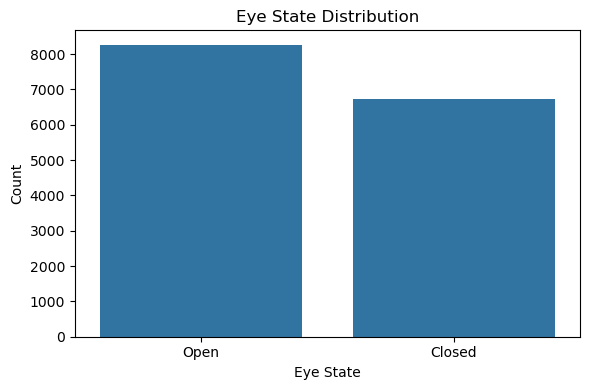

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x='eyeDetection',
    data=df
)

plt.title('Eye State Distribution')
plt.xlabel('Eye State')
plt.ylabel('Count')

plt.xticks(
    [0, 1],
    ['Open', 'Closed']
)

plt.tight_layout()

plt.savefig(
    '../images/eye_state_distribution.png',
    bbox_inches='tight'
)

plt.show()

#### Observation

The distribution of eye states was examined to determine whether the dataset is balanced. A balanced target variable helps machine learning models learn both classes effectively and reduces the risk of biased predictions.

In [16]:
df['eyeDetection'].value_counts()

eyeDetection
0    8257
1    6723
Name: count, dtype: int64

In [17]:
eye_state_percentages = (
    df['eyeDetection']
    .value_counts(normalize=True) * 100
)

print(eye_state_percentages)

eyeDetection
0    55.12016
1    44.87984
Name: proportion, dtype: float64


#### Observation

The target variable is relatively balanced, with 8,257 observations (55.12%) representing eyes open and 6,723 observations (44.88%) representing eyes closed. Since both classes are well represented, the dataset is suitable for machine learning classification without requiring class balancing techniques such as oversampling or undersampling. This balanced distribution helps reduce the risk of model bias toward a particular eye state.

In [18]:
df.describe()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
count,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000
mean,4321.917777,4009.767694,4264.022433,4164.946326,4341.741075,4644.022379,4110.400160,4616.056904,4218.826610,4231.316200,4202.456900,4279.232774,4615.205336,4416.435832,0.448798
std,2492.072174,45.941672,44.428052,5216.404632,34.738821,2924.789537,4600.926543,29.292603,2136.408523,38.050903,37.785981,41.544312,1208.369958,5891.285043,0.497388
min,1030.770000,2830.770000,1040.000000,2453.330000,2089.740000,2768.210000,2086.150000,4567.180000,1357.950000,1816.410000,3273.330000,2257.950000,86.666700,1366.150000,0.000000
25%,4280.510000,3990.770000,4250.260000,4108.210000,4331.790000,4611.790000,4057.950000,4604.620000,4190.770000,4220.510000,4190.260000,4267.690000,4590.770000,4342.050000,0.000000
50%,4294.360000,4005.640000,4262.560000,4120.510000,4338.970000,4617.950000,4070.260000,4613.330000,4199.490000,4229.230000,4200.510000,4276.920000,4603.080000,4354.870000,0.000000
75%,4311.790000,4023.080000,4270.770000,4132.310000,4347.180000,4626.670000,4083.590000,4624.100000,4209.230000,4239.490000,4211.280000,4287.180000,4617.440000,4372.820000,1.000000
max,309231.000000,7804.620000,6880.510000,642564.000000,6474.360000,362564.000000,567179.000000,7264.100000,265641.000000,6674.360000,6823.080000,7002.560000,152308.000000,715897.000000,1.000000


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AF3,14980.0,4321.917777,2492.072174,1030.7700,4280.51,4294.36,4311.79,309231.00
F7,14980.0,4009.767694,45.941672,2830.7700,3990.77,4005.64,4023.08,7804.62
F3,14980.0,4264.022433,44.428052,1040.0000,4250.26,4262.56,4270.77,6880.51
FC5,14980.0,4164.946326,5216.404632,2453.3300,4108.21,4120.51,4132.31,642564.00
T7,14980.0,4341.741075,34.738821,2089.7400,4331.79,4338.97,4347.18,6474.36
P7,14980.0,4644.022379,2924.789537,2768.2100,4611.79,4617.95,4626.67,362564.00
O1,14980.0,4110.400160,4600.926543,2086.1500,4057.95,4070.26,4083.59,567179.00
O2,14980.0,4616.056904,29.292603,4567.1800,4604.62,4613.33,4624.10,7264.10
P8,14980.0,4218.826610,2136.408523,1357.9500,4190.77,4199.49,4209.23,265641.00
T8,14980.0,4231.316200,38.050903,1816.4100,4220.51,4229.23,4239.49,6674.36


#### Observation

The EEG channels exhibit different ranges and levels of variability. Most channel values are concentrated around 4,000 to 4,600 units; however, several channels contain extremely large maximum values compared to their means and quartiles. This suggests the presence of significant outliers or signal artifacts, which are common in EEG recordings due to eye movements, muscle activity, or recording noise. Further visual exploration is required to better understand the distribution of EEG signals across channels.

### Correlation Heatmap

A correlation heatmap was generated to examine the relationships among EEG channels. Correlation analysis helps identify channels that exhibit similar signal patterns and provides insights into potential dependencies between different brain regions. Understanding these relationships can also help detect redundant features and improve model interpretation.

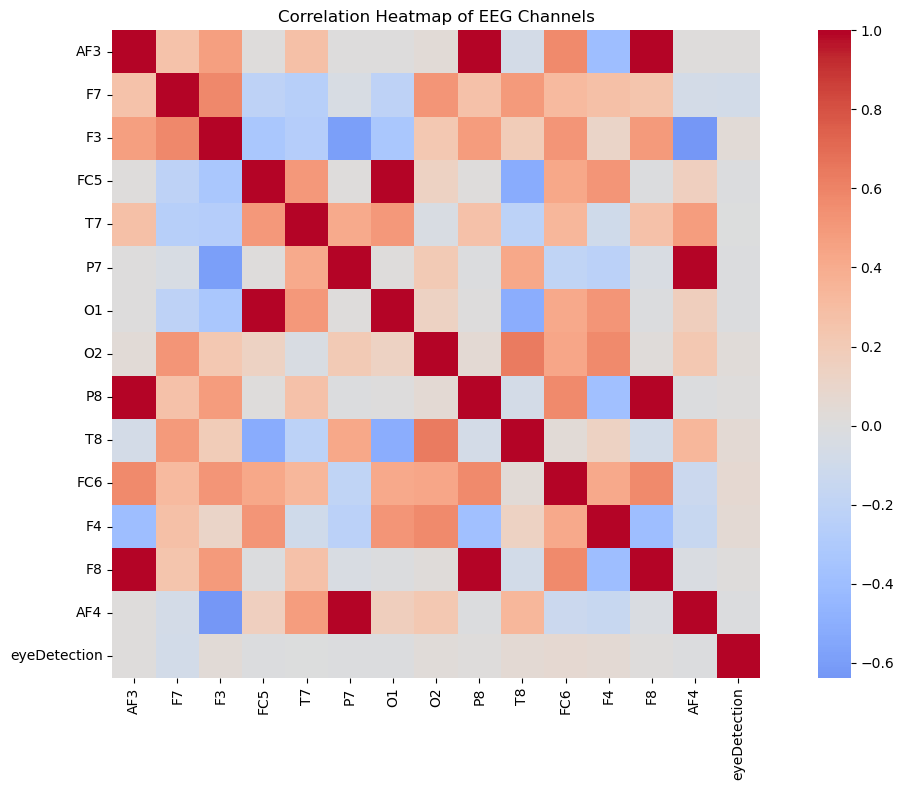

In [20]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title('Correlation Heatmap of EEG Channels')

plt.tight_layout()

plt.savefig(
    '../images/correlation_heatmap.png',
    bbox_inches='tight'
)

plt.show()

#### Observation

The correlation heatmap reveals several strong positive correlations among EEG channels, indicating that certain brain regions exhibit similar signal patterns. A few strong negative correlations are also observed, suggesting inverse relationships between specific channels. These findings are expected in EEG data because neighboring or functionally related brain regions often produce correlated electrical activity. The presence of correlated features provides valuable insight into the underlying brain signal structure and may influence model interpretation.

### Distribution of EEG Channels

Histograms were generated to examine the distribution of EEG signal values across channels and identify potential outliers, skewness, or unusual signal patterns.

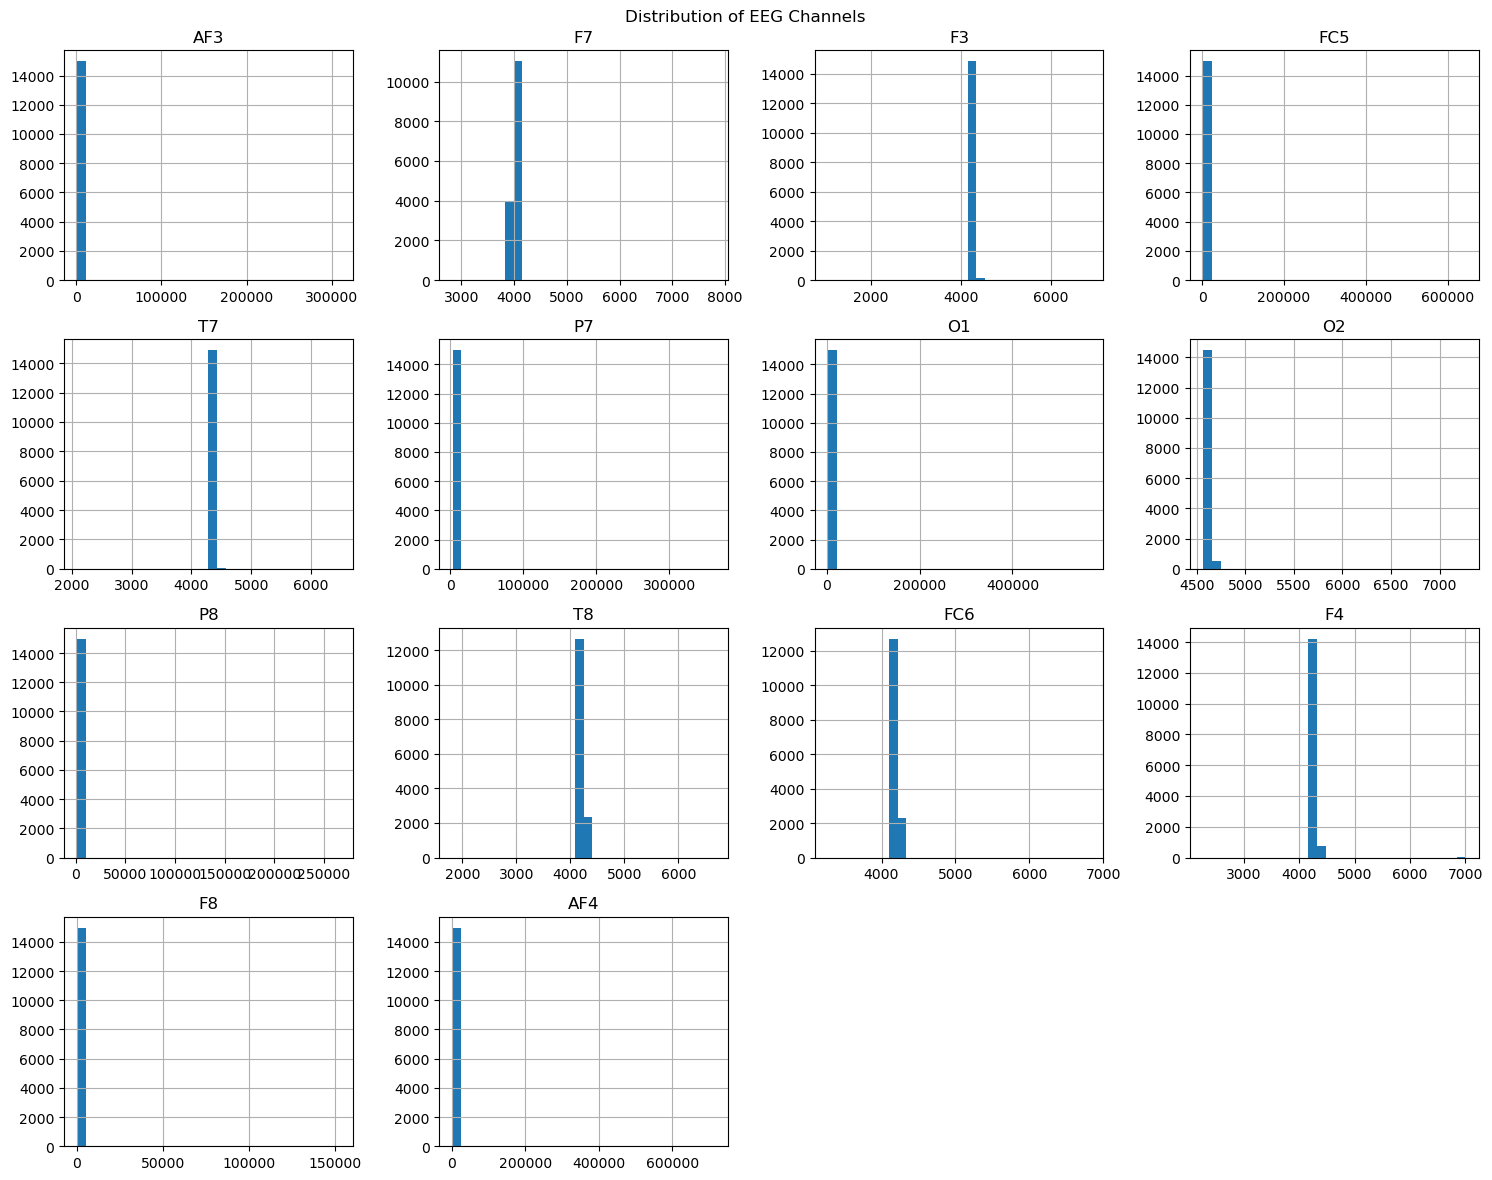

In [21]:
df.iloc[:, :-1].hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle('Distribution of EEG Channels')

plt.tight_layout()

plt.savefig(
    '../images/eeg_channel_distribution.png',
    bbox_inches='tight'
)

plt.show()

#### Observation

The EEG channel distributions reveal that most signal values are concentrated within a relatively narrow range. However, several channels contain extreme values that are substantially larger than the typical observations. These extreme values are likely caused by EEG artifacts, recording noise, eye blinks, or muscle movements, which are common in EEG recordings. Despite the presence of outliers, the majority of EEG measurements appear stable and suitable for machine learning analysis.

### EEG Channel Boxplots

Boxplots were created to visualize the spread of EEG signal values across all channels and to identify potential outliers. Outlier detection is particularly important in EEG analysis because artifacts such as eye blinks, muscle movements, and recording noise can introduce unusually large signal values.

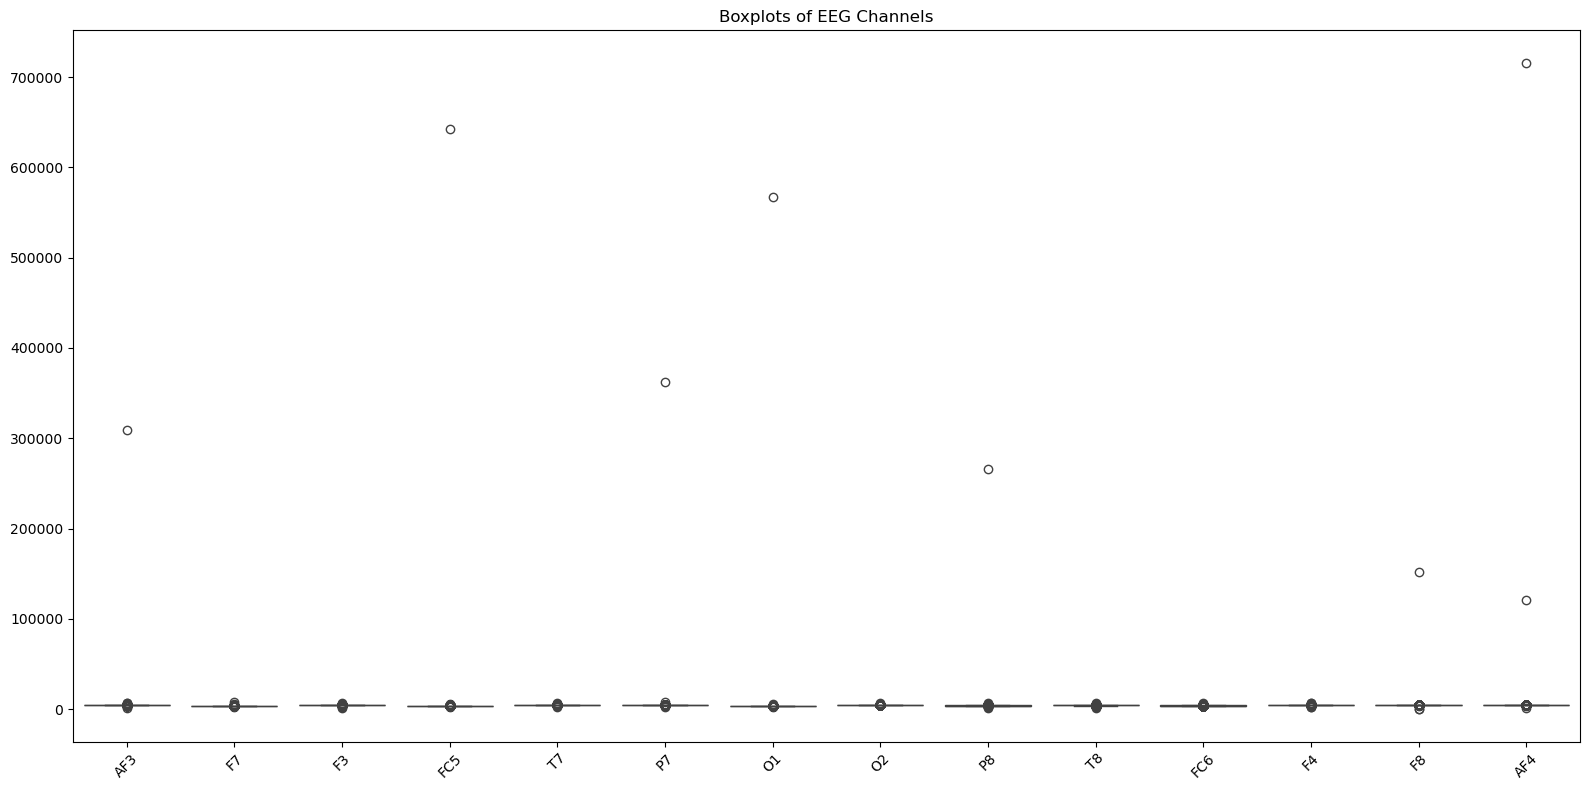

In [22]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df.iloc[:, :-1])

plt.title("Boxplots of EEG Channels")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/eeg_channel_boxplots.png",
    bbox_inches="tight"
)

plt.show()

#### Observation

The boxplots indicate that several EEG channels contain extreme outliers, while the majority of observations are concentrated within a relatively narrow range. Because the outliers are substantially larger than the typical EEG signal values, the boxes appear compressed on the shared y-axis. These extreme values are likely caused by EEG artifacts or recording noise rather than representing the typical distribution of brain activity. At this stage, the outliers are retained to preserve the original characteristics of the dataset for baseline model development.

### 4. Feature Engineering

Feature engineering prepares the dataset for machine learning by separating the input features from the target variable and applying appropriate preprocessing techniques. Since all EEG channels are already numerical and the dataset contains no missing values, minimal preprocessing is required. Feature scaling is applied to improve the performance of algorithms that are sensitive to differences in feature magnitude, such as Logistic Regression.

In [23]:
X = df.drop('eyeDetection', axis=1)
y = df['eyeDetection']

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (14980, 14)
Target Vector Shape: (14980,)


#### Observation

The dataset was divided into input features (`X`) and the target variable (`y`). The feature matrix consists of 14 EEG channels, while the target variable represents the eye state (open or closed).

### Train-Test Split

The dataset was divided into training and testing sets to evaluate model performance on unseen data. An 80:20 split was used, where 80% of the observations were allocated for training and the remaining 20% for testing. Stratified sampling was applied to preserve the class distribution in both subsets.

In [24]:
from sklearn.model_selection import train_test_split

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (11984, 14)
Testing Set: (2996, 14)


In [25]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Observation

Feature standardization was applied using StandardScaler to normalize the EEG channel values. The scaler was fitted only on the training data and subsequently applied to the testing data to prevent data leakage. This preprocessing step is particularly important for Logistic Regression, whereas Random Forest can effectively operate on the original feature scales.

### 5. Logistic Regression

Logistic Regression was selected as the first baseline machine learning model for EEG Eye State Classification. Although its name contains the term "Regression," it is a classification algorithm that estimates the probability of an observation belonging to a particular class. In this project, Logistic Regression predicts whether a person's eyes are open or closed based on EEG signals recorded from 14 scalp electrodes.

In [26]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression Model

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [27]:
y_pred_lr = log_reg.predict(X_test_scaled)

In [28]:
y_prob_lr = log_reg.predict_proba(X_test_scaled)

In [29]:
pd.DataFrame(
    y_prob_lr[:5],
    columns=["Open", "Closed"]
)

,Open,Closed
0,0.558118,0.441882
1,0.567434,0.432566
2,0.704340,0.295660
3,0.582510,0.417490
4,0.517448,0.482552


In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

Accuracy: 0.585113484646195
Precision: 0.5576923076923077
Recall: 0.36654275092936806
F1 Score: 0.44235082996859576
ROC-AUC: 0.5648582924846719


In [32]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.60      0.76      0.67      1651
           1       0.56      0.37      0.44      1345

    accuracy                           0.59      2996
   macro avg       0.58      0.56      0.56      2996
weighted avg       0.58      0.59      0.57      2996



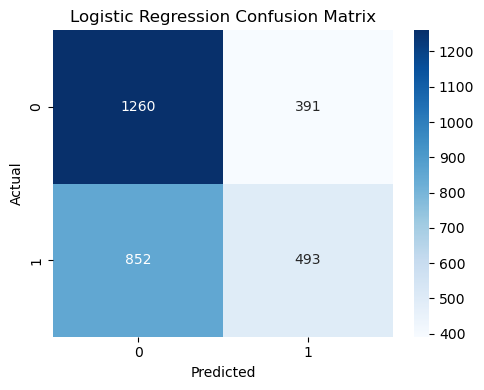

In [33]:
cm = confusion_matrix(y_test, y_pred_lr)

plt. figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../images/logistic_regression_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

#### Logistic Regression Performance

The performance of the Logistic Regression model was evaluated using multiple classification metrics, including Accuracy, Precision, Recall, F1-Score, ROC-AUC, and the Confusion Matrix. Using several evaluation metrics provides a more comprehensive assessment of the model's ability to distinguish between open and closed eye states than relying on accuracy alone.

#### Observation

The Logistic Regression model achieved an accuracy of **58.51%** and a **ROC-AUC score of 0.606**, indicating limited predictive performance for EEG Eye State Classification. While the model correctly classified many open-eye observations, it struggled to identify closed-eye instances, resulting in relatively low Recall and F1-Score. These findings suggest that EEG signals exhibit complex, non-linear relationships that are not adequately captured by a linear classifier, making Logistic Regression a suitable baseline model but not the optimal choice for this dataset.

### 6. Random Forest

Random Forest was selected as a non-linear machine learning model to classify EEG eye states. Unlike Logistic Regression, Random Forest constructs an ensemble of decision trees and combines their predictions to improve classification performance. This approach enables the model to capture complex relationships among EEG channels and is generally more robust to outliers and noisy data.

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf[:, 1]))

Accuracy: 0.9309078771695594
Precision: 0.9438377535101404
Recall: 0.8996282527881041
F1 Score: 0.9212028930338789
ROC-AUC: 0.9813946262150459


In [38]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1651
           1       0.94      0.90      0.92      1345

    accuracy                           0.93      2996
   macro avg       0.93      0.93      0.93      2996
weighted avg       0.93      0.93      0.93      2996



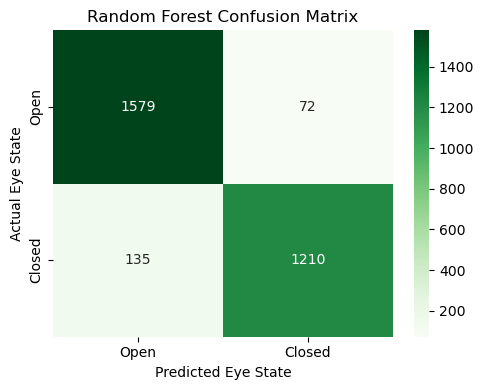

In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))

sns.heatmap(
    data=cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Open', 'Closed'],
    yticklabels=['Open', 'Closed']
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted Eye State")

plt.ylabel("Actual Eye State")

plt.tight_layout()

plt.savefig(
    "../images/random_forest_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

#### Observation

The Random Forest model achieved an accuracy of **93.09%**, substantially outperforming the Logistic Regression baseline. It demonstrated excellent Precision (94.38%), Recall (89.96%), F1-Score (92.12%), and ROC-AUC (98.14%), indicating a strong ability to distinguish between open and closed eye states. These results suggest that Random Forest effectively captures the complex, non-linear relationships present in EEG signals and is well suited for EEG Eye State Classification.

In [40]:
# Logistic Regression Metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr[:, 1])

# Random Forest Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf[:, 1])

### 7. Model Comparison

The performance of Logistic Regression and Random Forest was compared using multiple evaluation metrics. Comparing multiple models provides insight into the strengths and limitations of each algorithm and helps identify the most suitable model for EEG Eye State Classification.

In [41]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1,
        lr_auc
    ],

    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

comparison.round(3)

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.585,0.931
1,Precision,0.558,0.944
2,Recall,0.367,0.900
3,F1-Score,0.442,0.921
4,ROC-AUC,0.606,0.981


#### Observation

The comparison demonstrates that Random Forest consistently outperformed Logistic Regression across all evaluation metrics. The most significant improvements were observed in Recall, F1-Score, and ROC-AUC, indicating a substantially better ability to distinguish between open and closed eye states. These results confirm that Random Forest is more effective at modeling the complex, non-linear patterns present in EEG signals and is therefore the preferred model for this classification task.

### 8. ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve was used to compare the classification performance of Logistic Regression and Random Forest across all possible classification thresholds. The Area Under the Curve (ROC-AUC) summarizes the model's ability to distinguish between the two eye states, where higher values indicate better classification performance.

In [42]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr[:, 1])

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf[:, 1])

In [43]:
lr_auc = roc_auc_score(y_test, y_prob_lr[:, 1])
rf_auc = roc_auc_score(y_test, y_prob_rf[:, 1])

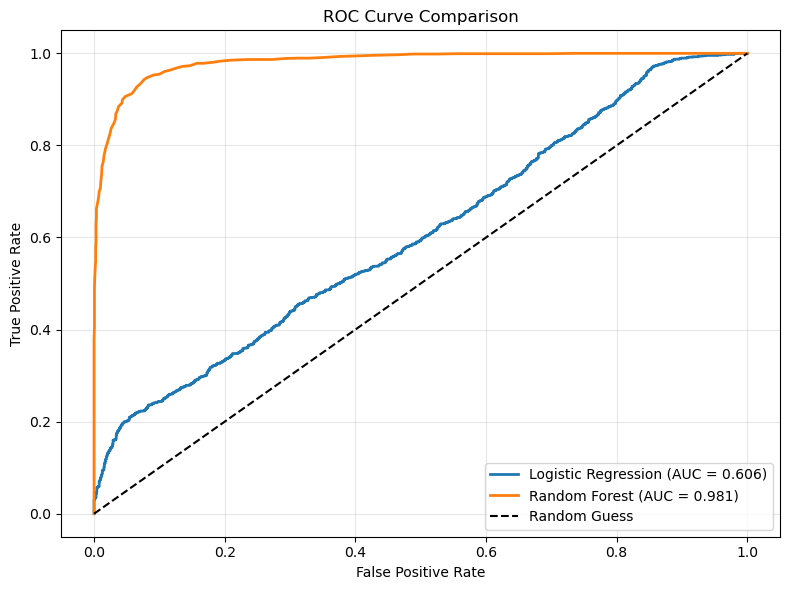

In [44]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})",
    linewidth=2
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The ROC curve comparison clearly demonstrates the superior performance of the Random Forest model. Its curve remains close to the upper-left corner of the graph, indicating a high true positive rate while maintaining a low false positive rate across different decision thresholds. In contrast, the Logistic Regression curve lies much closer to the diagonal reference line, reflecting weaker discrimination between open and closed eye states. The substantial difference in ROC-AUC values further confirms that Random Forest is the more effective model for EEG Eye State Classification.

### 9. Feature Importance

Random Forest provides an estimate of feature importance by measuring how much each feature contributes to reducing prediction error across all decision trees. Analyzing feature importance helps identify which EEG channels play the greatest role in distinguishing between open and closed eye states.

In [45]:
feature_importance = pd.DataFrame({
    "EEG Channel": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,EEG Channel,Importance
6,O1,0.119790
5,P7,0.104545
1,F7,0.091194
12,F8,0.080284
0,AF3,0.079377
13,AF4,0.076472
11,F4,0.061178
3,FC5,0.060970
10,FC6,0.060175
9,T8,0.058252


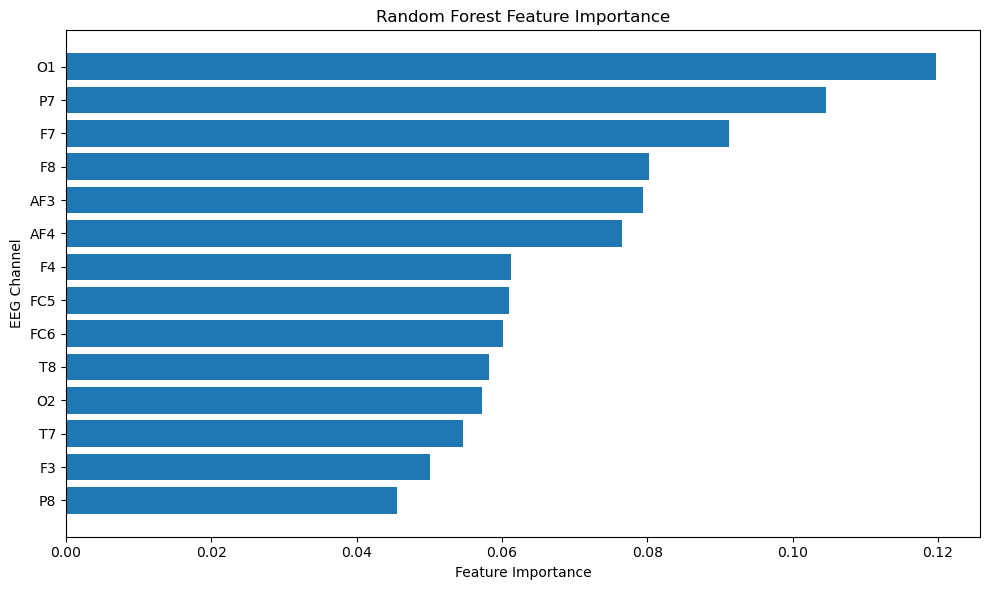

In [46]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["EEG Channel"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")

plt.ylabel("EEG Channel")

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The feature importance analysis indicates that the Random Forest model utilized information from all 14 EEG channels when classifying eye states. The O1 channel exhibited the highest importance score, followed by P7 and F7, suggesting that these electrodes contributed most strongly to the model's predictions. Notably, occipital and frontal channels ranked among the most influential features, which is consistent with the expectation that eye opening and closing affect visual processing and electrical activity recorded near the frontal region. The distribution of feature importance values also indicates that the model benefited from combining information across multiple EEG channels rather than relying on a single electrode.

### 10. Medical & Business Implications

This project demonstrates how machine learning can classify eye states from EEG signals with high accuracy. Although the dataset used in this project was collected for research purposes, similar techniques have practical applications in healthcare, neuroscience, and human-computer interaction.

#### Medical Applications

* **Brain-Computer Interfaces (BCIs):** EEG-based eye state detection can help individuals with severe physical disabilities communicate or control external devices without using traditional input methods.

* **Patient Monitoring:** Continuous EEG monitoring can assist clinicians in tracking patient alertness, fatigue, or consciousness during medical procedures.

* **Sleep Analysis:** Eye state detection can contribute to sleep stage analysis and support the diagnosis of sleep-related disorders.

* **Neurological Research:** Machine learning models can help researchers analyze EEG patterns associated with neurological conditions such as epilepsy, Alzheimer's disease, and Parkinson's disease.

#### Business and Industrial Applications

* **Driver Fatigue Detection:** EEG-based systems can monitor driver alertness and issue warnings when signs of drowsiness are detected.

* **Workplace Safety:** Industries requiring continuous attention, such as aviation or manufacturing, can use EEG monitoring to improve operator safety.

* **Human-Computer Interaction:** Eye state recognition can improve adaptive interfaces, virtual reality systems, and assistive technologies.

Overall, this project demonstrates the potential of machine learning to transform complex EEG signals into meaningful predictions that may support future intelligent healthcare and monitoring systems.

### 11. Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning was performed to optimize the Random Forest classifier. Instead of relying on the default model settings, GridSearchCV was used to evaluate multiple combinations of hyperparameters using five-fold cross-validation. The objective was to identify the model configuration that produced the highest classification performance while improving generalization.

In [47]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    "n_estimators": [100, 200],

    "max_depth": [10, 20, None],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]

}

In [48]:
grid_search = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [49]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [50]:
print("Best Cross Validation Accuracy:")

print(grid_search.best_score_)

Best Cross Validation Accuracy:
0.9238985780082644


In [51]:
best_rf = grid_search.best_estimator_

In [52]:
y_pred_best = best_rf.predict(X_test)

y_prob_best = best_rf.predict_proba(X_test)

In [53]:
print("Accuracy :", accuracy_score(y_test, y_pred_best))

print("Precision :", precision_score(y_test, y_pred_best))

print("Recall :", recall_score(y_test, y_pred_best))

print("F1 Score :", f1_score(y_test, y_pred_best))

print("ROC AUC :", roc_auc_score(y_test, y_prob_best[:,1]))

Accuracy : 0.9335781041388518
Precision : 0.9462616822429907
Recall : 0.9033457249070632
F1 Score : 0.9243058197033093
ROC AUC : 0.9820712466703743


In [54]:
tuning_comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"

    ],

    "Original Random Forest":[

        accuracy_score(y_test,y_pred_rf),

        precision_score(y_test,y_pred_rf),

        recall_score(y_test,y_pred_rf),

        f1_score(y_test,y_pred_rf),

        roc_auc_score(y_test,y_prob_rf[:,1])

    ],

    "Tuned Random Forest":[

        accuracy_score(y_test,y_pred_best),

        precision_score(y_test,y_pred_best),

        recall_score(y_test,y_pred_best),

        f1_score(y_test,y_pred_best),

        roc_auc_score(y_test,y_prob_best[:,1])

    ]

})

tuning_comparison.round(3)

,Metric,Original Random Forest,Tuned Random Forest
0,Accuracy,0.931,0.934
1,Precision,0.944,0.946
2,Recall,0.900,0.903
3,F1 Score,0.921,0.924
4,ROC AUC,0.981,0.982


### 12. Project Conclusion

This project successfully developed and evaluated machine learning models for EEG Eye State Classification using EEG signals collected from 14 scalp electrodes.

The dataset was thoroughly explored through data cleaning and exploratory data analysis (EDA), which confirmed that it contained no missing values and a relatively balanced distribution of eye states. Statistical analysis, correlation analysis, distribution analysis, and outlier visualization provided valuable insights into the characteristics of the EEG signals before model development.

Two machine learning algorithms were implemented: Logistic Regression and Random Forest. Logistic Regression served as the baseline model but achieved limited predictive performance, indicating that the relationship between EEG signals and eye states is not purely linear. The Random Forest classifier significantly outperformed the baseline model by effectively capturing the complex patterns present in the EEG data.

To further improve performance, hyperparameter tuning was performed using GridSearchCV with five-fold cross-validation. The optimized Random Forest model achieved an **Accuracy of 93.36%**, **Precision of 94.63%**, **Recall of 90.33%**, **F1-Score of 92.43%**, and a **ROC-AUC score of 0.982**, demonstrating excellent predictive performance and strong generalization capability.

Feature importance analysis revealed that all fourteen EEG channels contributed to the classification process, with the **O1** channel being the most influential feature, followed by **P7** and **F7**. This indicates that the model learned meaningful information from multiple EEG electrodes rather than relying on a single channel.

Overall, this project demonstrates a complete end-to-end machine learning workflow, including data preprocessing, exploratory data analysis, model development, hyperparameter tuning, model evaluation, interpretation, and practical application. The results highlight the effectiveness of machine learning for analyzing complex biomedical signals and illustrate its potential applications in brain-computer interfaces, patient monitoring, fatigue detection, neuroscience research, and intelligent healthcare systems.

### 13. Project Limitations

Although the optimized Random Forest model achieved excellent predictive performance, this project has several limitations that should be considered.

* The model was trained and evaluated using a single publicly available EEG dataset. Its performance may differ when applied to data collected from different EEG devices, recording environments, or participant populations.

* The dataset focuses only on binary eye state classification (eyes open or eyes closed). It does not include more complex cognitive or neurological states.

* While Random Forest provides feature importance, it does not fully explain the underlying physiological relationships between EEG signals and eye states. More advanced explainable AI techniques, such as SHAP or LIME, could provide deeper insights into model predictions.

* The project used raw EEG channel values without extensive signal preprocessing. Advanced preprocessing techniques such as filtering, artifact removal, frequency-domain feature extraction, or wavelet analysis could further improve model performance.

* Hyperparameter tuning was performed using a relatively small search space to balance computational efficiency and model optimization. Exploring a larger range of hyperparameters may yield additional performance improvements.

* The project focused on offline EEG analysis. Deploying the model for real-time EEG eye state classification would require further optimization for low-latency prediction and integration with live EEG acquisition systems.

### 14. Future Improvements

Several enhancements can be explored to further improve this project and extend its real-world applicability.

* Evaluate additional machine learning algorithms such as XGBoost, LightGBM, Support Vector Machines (SVM), Gradient Boosting, and Extra Trees Classifier.

* Perform more extensive hyperparameter optimization using RandomizedSearchCV, Bayesian Optimization, or Optuna to efficiently search larger hyperparameter spaces.

* Apply advanced EEG preprocessing techniques, including band-pass filtering, Independent Component Analysis (ICA), artifact removal, and frequency-domain feature extraction.

* Develop deep learning models such as Convolutional Neural Networks (CNNs), Long Short-Term Memory (LSTM) networks, or Transformer-based architectures for automatic feature learning from EEG signals.

* Validate the trained model using external EEG datasets collected from different participants and recording devices to evaluate its generalization capability.

* Deploy the optimized model as a real-time EEG eye state monitoring system integrated with Brain-Computer Interface (BCI) applications.

* Investigate explainable AI (XAI) methods such as SHAP and LIME to improve model interpretability and better understand how EEG channels influence predictions.

### 15. Final Takeaway

This project demonstrates a complete end-to-end machine learning workflow for biomedical signal analysis, beginning with data loading and preprocessing and continuing through exploratory data analysis, model development, hyperparameter tuning, model evaluation, feature importance analysis, and interpretation of real-world applications.

The optimized Random Forest model achieved an accuracy of **93.36%** and a **ROC-AUC score of 0.982**, demonstrating that machine learning can effectively learn meaningful patterns from EEG signals for eye state classification.

Beyond achieving strong predictive performance, this project emphasizes the importance of understanding data quality, selecting appropriate evaluation metrics, interpreting model behavior, and connecting technical results to practical healthcare applications. The knowledge and techniques developed throughout this project provide a strong foundation for more advanced EEG analysis, brain-computer interface development, and future machine learning projects in healthcare and neuroscience.

---
**Project Status:** ✅ Completed

This project demonstrates an end-to-end machine learning workflow for EEG Eye State Classification and is included in my Data Science Portfolio.